In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import seaborn as sns

In [2]:
df=pd.read_csv("DataSets\\house_prices_mlr.csv")
df.head()

,area,bedrooms,age,price
0,850,2,5,46.2
1,900,2,4,42.1
2,1000,3,6,55.8
3,1200,3,8,62.9
4,1500,4,10,76.3


In [4]:
df.shape

(70, 4)

In [5]:
df.describe()

,area,bedrooms,age,price
count,70.000000,70.000000,70.000000,70.000000
mean,1306.714286,3.214286,10.142857,68.285714
std,426.416553,1.101946,4.511774,23.010768
min,700.000000,1.000000,4.000000,32.400000
25%,980.000000,2.000000,6.000000,49.650000
50%,1250.000000,3.000000,9.000000,65.800000
75%,1600.000000,4.000000,13.000000,82.975000
max,2400.000000,5.000000,22.000000,127.800000


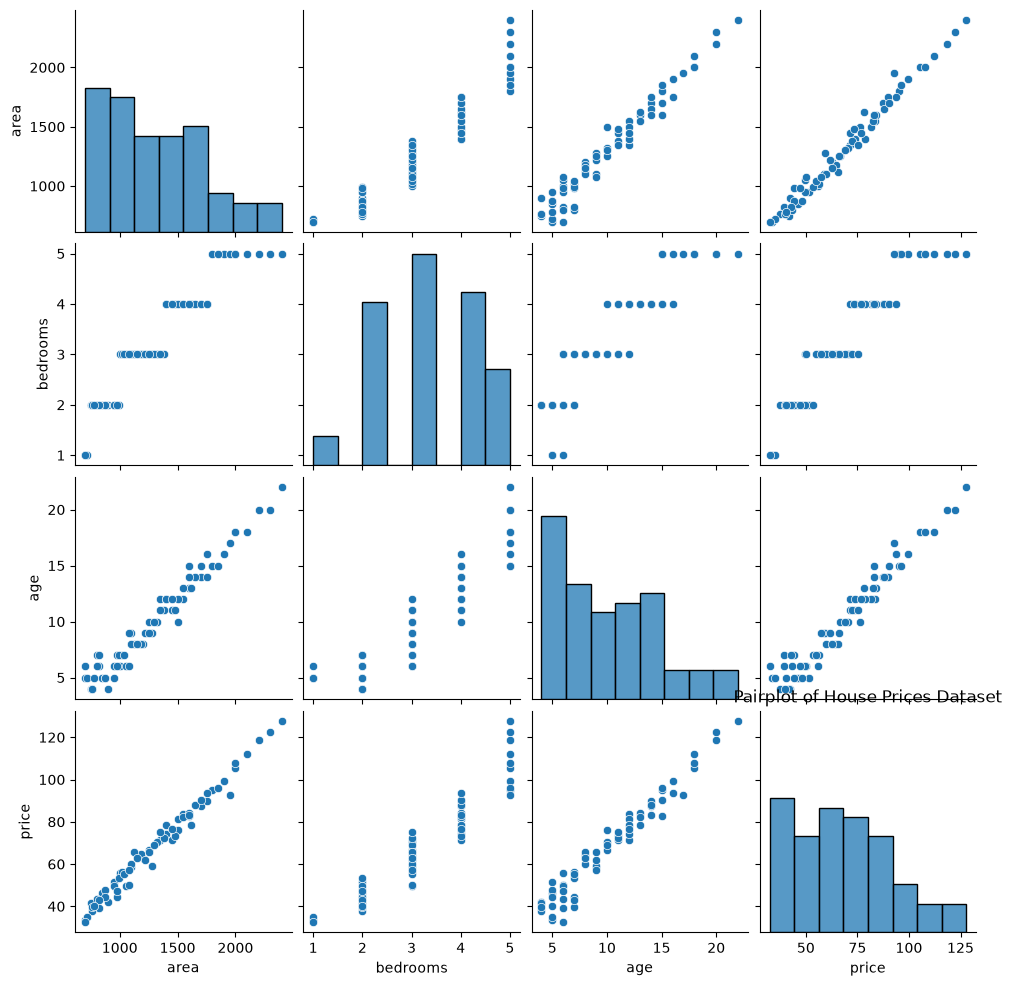

In [6]:
sns.pairplot(df)
plt.title('Pairplot of House Prices Dataset')
plt.show()

In [9]:
X=df[['area', 'bedrooms', 'age']]
y=df['price']

In [10]:
X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 14
Testing set size: 56


In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.05,-2.34, 0.41]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['area','bedrooms','age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.5962
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [14]:
y_pred = model.predict(X_test)
sample_pred=model.predict([[1300,3,10]])
print("Predicted price for area=10, bedrooms=56, age=1:", sample_pred[0])

Predicted price for area=10, bedrooms=56, age=1: 66.4276292912336


c:\Users\amitc\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
r2=model.score(X_test, y_test)
print("R-squared value:", r2)

R-squared value: 0.9694480326048597


In [16]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 3.489033984552332
Mean Squared Error (MSE): 16.092743782663852
Root Mean Squared Error (RMSE): 4.01157622171932
